# AO performance modelling with TIPTOP: atmosphere, guide-star geometry, and numerical convergence

This supplemental study retains the representative 8 m, eight-LGS, three-DM configuration adapted from the public P3 `MavisMCAO.ini` example. It is not an official instrument model or an on-sky prediction.

**What is computed.** TIPTOP/P3 supplies the high-order residual PSD and its error decomposition. The notebook also reports a **tail-completed model**: the native finite-grid fitting term is replaced by the continuous von Kármán fitting structure function, with PSFs propagated by MASTSEL. Raw P3 outputs remain visible and are never relabeled as corrected native outputs. The science crop retains the normalization of an extended computational image.

Seeing, outer scale, vertical turbulence distribution, and guide-star asterism radius are varied independently. Five figures show the baseline PSFs, seeing sensitivity, atmospheric structure, asterism geometry, and error budgets. Numerical convergence is checked before interpreting these sweeps.

## 1. Environment and method

The adapter in `tiptop_support.py` is deliberately scoped to this CPU, single-wavelength, high-order-only configuration, with a circular DM cutoff and no static OPD, jitter, low-order residual, or additional error PSD. It rejects unsupported branches. Nothing in the installed TIPTOP, P3, or MASTSEL packages is patched.

Use Python 3.11 or newer and install the optional notebook environment from the repository root:

```sh
python -m pip install -e ".[tiptop,notebooks]"
```

Verified versions: `astro-tiptop==1.5.1`, `astro-p3==1.6.2`, `mastsel==1.5.2`. The executable version check below rejects unverified environments rather than silently assuming an unchanged API. The CPU-fallback messages are informational.


In [1]:
from __future__ import annotations
import copy
import json
import os
import sys
import tempfile
import time
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "notebooks" / "studies"))
from tiptop_support import (BUDGET_ATTRIBUTES, RAD_TO_MAS, check_versions, complete_psfs,
                            centered_crop, encircled_energy_at, fitting_variance,
                            fwhm_contour)
from tiptop.baseSimulation import baseSimulation
print(check_versions())
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.22, "legend.frameon": False})
RAD2MAS = RAD_TO_MAS
FIG_DIR = ROOT / "figures"
RUN_DIR = Path(tempfile.mkdtemp(prefix="tiptop_completed_"))
ALL_RUNS = []

Cupy import failed. P3 will fall back to CPU use.


Cupy import failed. MASTSEL will fall back to CPU use.


Cupy import failed. SEEING will fall back to CPU use.


{'astro-tiptop': '1.5.1', 'astro-p3': '1.6.2', 'mastsel': '1.5.2'}


## 2. Representative baseline and conventions

The baseline retains the original public-example-derived atmospheric profile, eight sodium guide stars at 90 km, 40×40 WFSs at 589 nm, and DMs conjugated to 0, 6 and 13.5 km. The 0–30 arcsec reconstruction field is held fixed during the asterism sweep. Science is H band, 1650 nm; the pupil has 14% central obscuration.

Seeing is specified at zenith at 500 nm. P3 applies airmass `X=sec(z)` and reports r0 at the science wavelength: `r0 ∝ X**(-3/5) * wavelength**(6/5)`. No natural-guide-star low-order loop is included. Consequently, these high-order-only results are optimistic compared with a delivered instrument budget, and do not validate controller stability.

**Numerical distinction.** The original 400-pixel, 5 mas science grid truncates the atmospheric fitting PSD soon above the DM cutoff. The new 1024-pixel computational image retains an analytic fitting tail extending to infinite frequency. Its central 400-pixel science crop is not renormalized. A 2048-pixel comparison below checks the remaining image-sampling and finite-field error.

In [2]:
# --- Baseline configuration -------------------------------------------------
# Adapted from the public p3/aoSystem/parFiles/MavisMCAO.ini (astro-p3 1.6.2).
# Values are REPRESENTATIVE of an 8 m-class LGS MCAO system; see Section 2.1.

SCIENCE_FIELD_ARCSEC = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
SCIENCE_WAVELENGTH_M = 1650e-9          # H band
N_LGS = 8
BASELINE_ASTERISM_RADIUS_ARCSEC = 17.5
EE_RADIUS_MAS = 50.0                    # radius for the fixed-aperture EE metric

BASELINE_CONFIG = {
    "telescope": {
        "TelescopeDiameter": 8.0,       # m
        "ObscurationRatio": 0.14,       # central obscuration / D
        "Resolution": 128,              # pupil sampling, px across D
        "ZenithAngle": 30.0,            # deg
    },
    "atmosphere": {
        "Wavelength": 500e-9,           # m, wavelength at which Seeing is defined
        "Seeing": 0.8,                  # arcsec AT ZENITH (see Section 2.5)
        "L0": 25.0,                     # m, outer scale
        "Cn2Weights": [0.59, 0.02, 0.04, 0.06, 0.01, 0.05, 0.09, 0.04, 0.05, 0.05],
        "Cn2Heights": [30, 140, 281, 562, 1125, 2250, 4500, 7750, 11000, 14000],  # m
        "WindSpeed": [6.6, 5.9, 5.1, 4.5, 5.1, 8.3, 16.3, 10.2, 14.3, 17.5],      # m/s
        "WindDirection": [0.0, 0.0, 0.0, 0.0, 90.0, -90.0, -90.0, 90.0, 0.0, 0.0],
    },
    "sources_science": {
        "Wavelength": [SCIENCE_WAVELENGTH_M],
        "Zenith": list(SCIENCE_FIELD_ARCSEC),                 # arcsec
        "Azimuth": [45.0] * len(SCIENCE_FIELD_ARCSEC),        # deg
    },
    "sources_HO": {
        "Wavelength": [589e-9],                               # sodium
        "Zenith": [BASELINE_ASTERISM_RADIUS_ARCSEC] * N_LGS,
        "Azimuth": [0, 45, 90, 135, 180, 225, 270, 315],
        "Height": 90e3,                                       # m, sodium layer
    },
    "sensor_science": {
        "PixelScale": 5.0,              # mas/px  (see the sampling check below)
        "FieldOfView": 400,             # px  -> 2.0 arcsec across
    },
    "sensor_HO": {
        "WfsType": "'Shack-Hartmann'",
        "PixelScale": 833,              # mas/px on the WFS detector
        "FieldOfView": 240,             # px per subaperture field
        "NumberPhotons": [75] * N_LGS,  # detected photons/subaperture/frame
        "SpotFWHM": [[1200.0, 2500.0, 0.0]],   # mas, elongated sodium spot
        "SigmaRON": 0.2,                # e-
        "ExcessNoiseFactor": 2.0,
        "NumberLenslets": [40] * N_LGS,
        "Algorithm": "'wcog'",
        "WindowRadiusWCoG": 5,
    },
    "DM": {
        "NumberActuators": [39, 39, 27],
        "DmPitchs": [0.22, 0.25, 0.35],           # m, on each meta-pupil
        "InfModel": "'gaussian'",
        "InfCoupling": [0.2, 0.2, 0.2],
        "DmHeights": [0, 6000, 13500],            # m, conjugation altitudes
        # Tomographic reconstruction optimised uniformly over the whole 0-30 arcsec
        # science field: 1 on-axis + 8 azimuths at 15" + 8 azimuths at 30".
        # Held FIXED across every sweep so that only the swept variable changes.
        "OptimizationZenith": [0] + [15] * 8 + [30] * 8,
        "OptimizationAzimuth": [0] + [0, 45, 90, 135, 180, 225, 270, 315] * 2,
        "OptimizationWeight": [1] * 17,
        "OptimizationConditioning": 1.0e2,
        "NumberReconstructedLayers": 10,
        "AoArea": "'circle'",
    },
    "RTC": {
        "LoopGain_HO": 0.4,
        "SensorFrameRate_HO": 1000.0,   # Hz
        "LoopDelaySteps_HO": 2,         # frames
    },
    "COMPUTATION": {
        "platform": "'CPU'",
    },
}

### 2.1 Runner and attribution

`baseSimulation` exposes the residual PSD, native PSFs and raw error terms. The adapter removes the native finite-grid fitting PSD exactly once, keeps all other P3 PSD components, and propagates the complete fitting structure function through MASTSEL. The non-fitting terms use the actual PSD frequency increment; the small difference from P3's rounded-grid increment is recorded explicitly.

The raw `fao.wfeFit`, `fao.wfeTot`, and native image metrics are retained. Completed budgets have separate names and close against the variance used in their OTF. Budget closure and a seeing power law alone are not absolute convergence tests.

In [3]:
def override(config, **sections):
    result = copy.deepcopy(config)
    for section, values in sections.items():
        result.setdefault(section, {}).update(values)
    return result


def config_to_ini(config):
    def literal(value):
        return value if isinstance(value, str) else repr(value)
    return "\n".join("[" + section + "]\n" + "\n".join(
        f"{key} = {literal(value)}" for key, value in entries.items())
        for section, entries in config.items())


@dataclass
class Run:
    name: str
    config: dict
    fao: object
    completed: object
    raw_psfs: np.ndarray
    raw_diffraction: np.ndarray
    raw_strehl: np.ndarray
    raw_fwhm: np.ndarray
    runtime_s: float

    @property
    def field(self):
        return np.array(self.config["sources_science"]["Zenith"])

    @property
    def psfs(self):
        return self.completed.psfs

    @property
    def strehl(self):
        return self.psfs.max(axis=(1, 2)) / self.completed.diffraction.max()

    @property
    def fwhm(self):
        return np.array([fwhm_contour(p, self.completed.pixel_scale_mas) for p in self.psfs])

    @property
    def ee50mas(self):
        return np.array([encircled_energy_at(p, self.completed.pixel_scale_mas, 50)
                         for p in self.psfs])


def run_tiptop(config, name, *, internal_pixels=1024, crop_pixels=400):
    (RUN_DIR / (name + ".ini")).write_text(config_to_ini(config))
    started = time.perf_counter()
    simulation = baseSimulation(str(RUN_DIR) + os.sep, name, str(RUN_DIR) + os.sep,
        name + "_out", doConvolve=True, doPlot=False, addSrAndFwhm=True,
        verbose=False, getHoErrorBreakDown=True, savePSDs=False,
        ensquaredEnergy=False, eeRadiusInMas=50)
    simulation.doOverallSimulation()
    simulation.computeMetrics()
    completed = complete_psfs(simulation.fao, crop_pixels=crop_pixels, internal_pixels=internal_pixels,
                              pixel_scale_mas=config["sensor_science"]["PixelScale"], quadrature_nodes=512)
    result = Run(name, copy.deepcopy(config), simulation.fao, completed,
        np.asarray(simulation.cubeResultsArray), np.asarray(simulation.psf_dl_array),
        np.asarray(simulation.sr), np.asarray(simulation.fwhm), time.perf_counter()-started)
    ALL_RUNS.append(result)
    return result


baseline = run_tiptop(BASELINE_CONFIG, "baseline")
atm = baseline.fao.ao.atm
r0_500_zenith = 0.976 * 500e-9 / (0.8 / 206264.80624709636)
r0_500_los = r0_500_zenith * np.cos(np.deg2rad(30))**0.6
expected_r0_H = r0_500_los * (1650/500)**1.2
assert np.isclose(atm.r0, expected_r0_H, rtol=1e-6)
print(f"r0: {r0_500_los:.6f} m at 500 nm along the line of sight; {atm.r0:.6f} m at H.")
print(f"Actual/P3 quadrature increment: {baseline.completed.p3_to_actual_df_ratio:.9f}")
print(f"Raw P3 fitting: {baseline.completed.raw_budget_nm['fitting'][0]:.3f} nm; "
      f"completed fitting: {baseline.completed.completed_budget_nm['fitting'][0]:.3f} nm.")

r0: 0.115418 m at 500 nm along the line of sight; 0.483604 m at H.
Actual/P3 quadrature increment: 0.998716183
Raw P3 fitting: 47.895 nm; completed fitting: 71.300 nm.


### 2.2 Metrics and flux conventions

All completed PSFs share a full-computational-field normalization. Strehl is their peak divided by the identically normalized diffraction reference peak. EE(50 mas) is the flux inside a circular 50 mas radius, with fractional boundary pixels; it is **not divided by the science-crop flux**. FWHM is the equivalent diameter of a linearly interpolated half-maximum core contour, rather than a count of pixels above half maximum.

Raw TIPTOP image Strehl is reported separately because both its finite PSD and its finite-image normalization differ. Maréchal Strehl is an approximation from completed residual WFE; it need not equal the propagated peak ratio for this structured, direction-dependent residual.

In [4]:
def metric_table(run):
    c = run.completed
    return pd.DataFrame({"field (arcsec)": run.field,
        "raw TIPTOP image Strehl": run.raw_strehl,
        "completed peak Strehl": run.strehl,
        "completed Marechal": np.exp(-(2*np.pi*c.total_nm/1650)**2),
        "completed FWHM (mas)": run.fwhm,
        "completed EE(50 mas)": run.ee50mas,
        "raw P3 total (nm)": c.raw_total_nm,
        "completed total (nm)": c.total_nm,
        "science-crop flux": c.crop_energy})

display(metric_table(baseline).round(6))
print("Diffraction reference contour FWHM:",
      round(fwhm_contour(baseline.completed.diffraction, 5), 4), "mas")

,field (arcsec),raw TIPTOP image Strehl,completed peak Strehl,completed Marechal,completed FWHM (mas),completed EE(50 mas),raw P3 total (nm),completed total (nm),science-crop flux
0,0.0,0.83491,0.780916,0.777657,43.280545,0.635403,120.762515,131.688318,0.951796
1,5.0,0.83418,0.780242,0.776305,43.284533,0.634676,121.259577,132.143121,0.951780
2,10.0,0.83645,0.782388,0.776398,43.300723,0.636306,121.225445,132.111881,0.951780
3,15.0,0.84134,0.787029,0.777419,43.347309,0.641449,120.849973,131.768319,0.951852
4,20.0,0.81006,0.757856,0.743409,43.454459,0.622599,133.031943,142.995580,0.951746
5,25.0,0.73406,0.686886,0.667071,43.666173,0.574640,158.709589,167.092038,0.951526
6,30.0,0.62628,0.586198,0.561026,44.051294,0.507238,192.766022,199.647288,0.951371


Diffraction reference contour FWHM: 43.112 mas


## 3. Numerical checks before the sensitivity study

Three distinct checks follow. (1) The 1024→2048 computational-image comparison and 256→512 radial-quadrature comparison exercise all seven science directions. (2) A full native P3/TIPTOP run with twice the science FoV independently exposes the finite fitting-tail deficit, while the tail-completed result is invariant to that input FoV. (3) A smaller science crop preserves overlapping pixels and their absolute flux.

The native wide run is a **reference with a remaining finite-tail error**, not an infinite-domain truth. Its raw budget and metrics are compared explicitly. The exact fitting integral is the absolute reference. A larger computational image tests PSF discretization separately from that physical integral.

A separate 5→2.5 mas focal-pixel refinement holds the 2 arcsec native FoV fixed and checks every science direction. This is distinct from enlarging the computational image at a fixed pixel scale. An independent analytic annular-Airy reference reports the absolute contour-sampling bias. The adapter uses P3's actual generated-pupil spacing, `D/(N-1)`; file-loaded pupils and apodizers are rejected because their coordinate scale is not validated here.


In [5]:
fine = complete_psfs(baseline.fao, crop_pixels=400, internal_pixels=2048,
                     pixel_scale_mas=5, quadrature_nodes=512)
quad256 = complete_psfs(baseline.fao, crop_pixels=400, internal_pixels=1024,
                        pixel_scale_mas=5, quadrature_nodes=256)

def completed_metrics(c):
    return np.array([c.psfs.max(axis=(1,2))/c.diffraction.max(),
        [encircled_energy_at(p,c.pixel_scale_mas,50) for p in c.psfs],
        [fwhm_contour(p,c.pixel_scale_mas) for p in c.psfs]])
base_metrics = completed_metrics(baseline.completed)
fine_metrics = completed_metrics(fine)
quad_metrics = completed_metrics(quad256)
convergence = pd.DataFrame({"field (arcsec)": baseline.field,
    "Strehl difference 1024->2048": fine_metrics[0]-base_metrics[0],
    "EE difference 1024->2048": fine_metrics[1]-base_metrics[1],
    "FWHM difference (mas)": fine_metrics[2]-base_metrics[2],
    "crop flux difference": fine.crop_energy-baseline.completed.crop_energy,
    "quadrature max relative change": np.max(abs(quad_metrics-base_metrics)/base_metrics,axis=0)})
display(convergence)
assert np.max(abs(fine_metrics[0]-base_metrics[0])) < 2e-4
assert np.max(abs(fine_metrics[1]-base_metrics[1])) < 3e-4
assert np.max(abs(fine_metrics[2]-base_metrics[2])) < 0.03
assert np.max(abs(quad_metrics-base_metrics)/base_metrics) < 1e-5
assert np.allclose(baseline.completed.full_grid_energy, 1, atol=1e-12)
assert np.allclose(fine.total_nm, baseline.completed.total_nm, atol=1e-10)
assert np.array_equal(centered_crop(baseline.psfs,200), baseline.psfs[:,100:300,100:300])
assert np.all(centered_crop(baseline.psfs,200).sum(axis=(1,2)) < baseline.completed.crop_energy)

wide = run_tiptop(override(BASELINE_CONFIG, sensor_science={"FieldOfView":800}), "wide_native_reference")
native_comparison = pd.DataFrame({"field (arcsec)": baseline.field,
    "raw fitting 400 (nm)":baseline.completed.raw_budget_nm["fitting"],
    "raw fitting 800 (nm)":wide.completed.raw_budget_nm["fitting"],
    "completed fitting (nm)":baseline.completed.completed_budget_nm["fitting"],
    "raw total 400 (nm)":baseline.completed.raw_total_nm,
    "raw total 800 (nm)":wide.completed.raw_total_nm,
    "completed total (nm)":baseline.completed.total_nm,
    "raw peak 400":(baseline.raw_psfs/baseline.raw_psfs.sum(axis=(1,2))[:,None,None]).max(axis=(1,2)) /
                   (baseline.raw_diffraction/baseline.raw_diffraction.sum()).max(),
    "raw peak 800":(wide.raw_psfs/wide.raw_psfs.sum(axis=(1,2))[:,None,None]).max(axis=(1,2)) /
                   (wide.raw_diffraction/wide.raw_diffraction.sum()).max(),
    "completed peak":baseline.strehl,
    "completed PSF max change":np.max(abs(wide.psfs-baseline.psfs),axis=(1,2))})
display(native_comparison.round(7))
assert np.max(abs(wide.psfs-baseline.psfs)) < 1e-12
assert np.allclose(wide.completed.total_nm,baseline.completed.total_nm,atol=1e-8)
assert np.all(wide.completed.raw_budget_nm['fitting'] < baseline.completed.completed_budget_nm['fitting'])
print("All-direction sampling, quadrature, crop, and input-FoV checks passed.")

# Refine actual focal-plane pixels, separately from internal image extent.
focal_refined = run_tiptop(override(BASELINE_CONFIG,
    sensor_science={"PixelScale":2.5,"FieldOfView":800}), "focal_refined",
    internal_pixels=2048,crop_pixels=800)
focal_metrics = completed_metrics(focal_refined.completed)
focal_convergence = pd.DataFrame({"field (arcsec)":baseline.field,
    "FWHM at 5 mas pixels":base_metrics[2],
    "FWHM at 2.5 mas pixels":focal_metrics[2],
    "FWHM relative change":focal_metrics[2]/base_metrics[2]-1,
    "peak Strehl change":focal_metrics[0]-base_metrics[0],
    "EE(50 mas) change":focal_metrics[1]-base_metrics[1]})
display(focal_convergence)
assert np.max(abs(focal_metrics[2]/base_metrics[2]-1)) < 0.02

# Analytic annular-Airy reference independent of P3 pupil autocorrelation.
from scipy.special import j1
from scipy.optimize import brentq
obscuration = BASELINE_CONFIG['telescope']['ObscurationRatio']
lambda_over_d_mas = SCIENCE_WAVELENGTH_M / 8 * RAD2MAS
def annular_intensity(u):
    u=np.asarray(u,dtype=float)
    safe=np.where(u==0,1,u)
    value=(2*(j1(safe)-obscuration*j1(obscuration*safe))/(safe*(1-obscuration**2)))**2
    return np.where(u==0,1,value)
continuous_fwhm=2*brentq(lambda u:float(annular_intensity(u))-.5,.01,3)/np.pi*lambda_over_d_mas
annular_rows=[]
for pixel in [5.,2.5]:
    q=(np.arange(101)-50)*pixel
    airy=annular_intensity(np.pi*np.hypot(q[:,None],q[None,:])/lambda_over_d_mas)
    sampled=fwhm_contour(airy,pixel)
    annular_rows.append({"pixel (mas)":pixel,"continuous annular FWHM (mas)":continuous_fwhm,
        "sampled contour FWHM (mas)":sampled,"fractional sampling bias":sampled/continuous_fwhm-1})
annular_reference=pd.DataFrame(annular_rows)
display(annular_reference)
assert abs(annular_rows[-1]['fractional sampling bias'])<abs(annular_rows[0]['fractional sampling bias'])
assert abs(annular_rows[-1]['fractional sampling bias'])<0.003
print("Focal-pixel refinement and independent annular-Airy reference passed.")


,field (arcsec),Strehl difference 1024->2048,EE difference 1024->2048,FWHM difference (mas),crop flux difference,quadrature max relative change
0,0.0,-7.203417e-07,-0.000009,-0.000040,-0.001807,7.145434e-13
1,5.0,-7.224036e-07,-0.000009,-0.000040,-0.001807,7.145911e-13
2,10.0,-7.184117e-07,-0.000009,-0.000040,-0.001807,9.883435e-13
3,15.0,-7.076100e-07,-0.000009,-0.000040,-0.001807,7.118140e-13
4,20.0,-7.500661e-07,-0.000009,-0.000044,-0.001807,7.088904e-13
5,25.0,-8.812304e-07,-0.000009,-0.000054,-0.001807,9.717731e-13
6,30.0,-1.098676e-06,-0.000008,-0.000073,-0.001807,6.948865e-13


,field (arcsec),raw fitting 400 (nm),raw fitting 800 (nm),completed fitting (nm),raw total 400 (nm),raw total 800 (nm),completed total (nm),raw peak 400,raw peak 800,completed peak,completed PSF max change
0,0.0,47.895476,64.920053,71.300348,120.762515,128.468758,131.688318,0.813138,0.791003,0.780916,0.0
1,5.0,47.895476,64.920053,71.300348,121.259577,128.936114,132.143121,0.812426,0.790327,0.780242,0.0
2,10.0,47.895476,64.920053,71.300348,121.225445,128.904016,132.111882,0.814629,0.792522,0.782389,0.0
3,15.0,47.895476,64.920053,71.300348,120.849973,128.550973,131.768319,0.819400,0.797263,0.787029,0.0
4,20.0,47.895476,64.920053,71.300348,133.031943,140.064751,142.995580,0.788932,0.767773,0.757856,0.0
5,25.0,47.895476,64.920053,71.300348,158.709589,164.649234,167.092038,0.714918,0.695965,0.686886,0.0
6,30.0,47.895476,64.920053,71.300348,192.766022,197.685042,199.647288,0.609942,0.594066,0.586198,0.0


All-direction sampling, quadrature, crop, and input-FoV checks passed.


,field (arcsec),FWHM at 5 mas pixels,FWHM at 2.5 mas pixels,FWHM relative change,peak Strehl change,EE(50 mas) change
0,0.0,43.280545,43.440975,0.003707,1.245062e-07,0.000024
1,5.0,43.284533,43.444991,0.003707,2.415699e-06,0.000027
2,10.0,43.300723,43.461220,0.003707,8.978216e-07,0.000029
3,15.0,43.347309,43.507701,0.003700,-1.027682e-06,0.000032
4,20.0,43.454459,43.614339,0.003679,2.429318e-07,0.000038
5,25.0,43.666173,43.824712,0.003631,6.755839e-06,0.000046
6,30.0,44.051294,44.206909,0.003533,1.125525e-05,0.000050


,pixel (mas),continuous annular FWHM (mas),sampled contour FWHM (mas),fractional sampling bias
0,5.0,43.303101,43.088079,-0.004966
1,2.5,43.303101,43.249712,-0.001233


Focal-pixel refinement and independent annular-Airy reference passed.


### 3.1 Figure 1 — baseline PSF

The completed PSF retains a narrow core and a broad halo. The science crop contains less than the full modeled energy, as it should. Normalizing each crop to one would inflate its peak and encircled energy. Increasing the internal image extent slightly reduces the halo folded into this crop; the convergence table quantifies that remaining numerical effect.

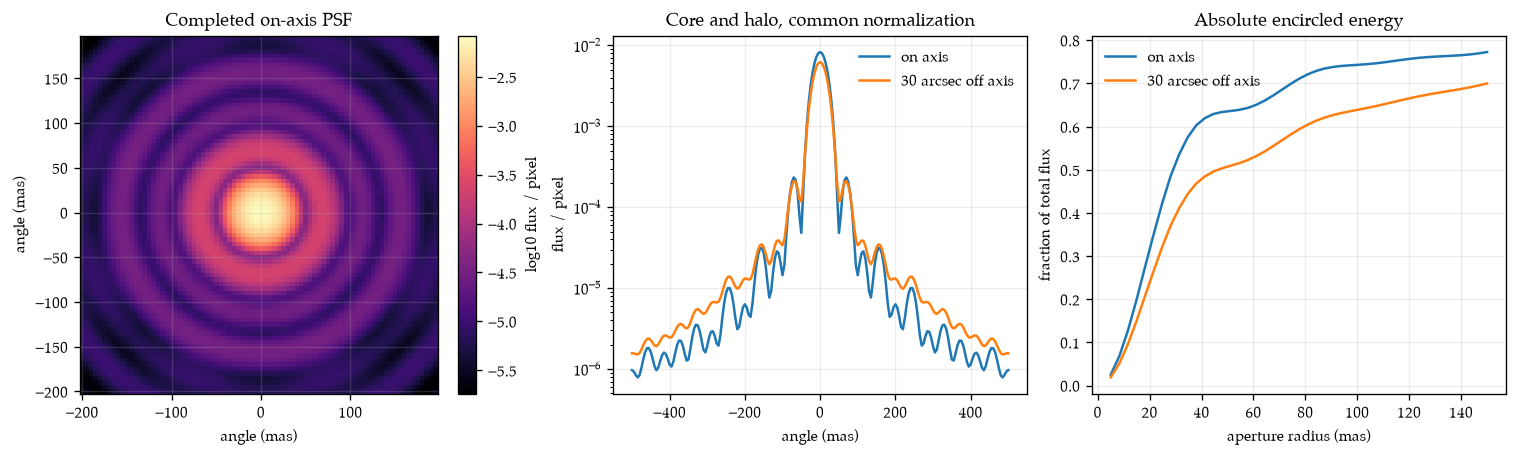

In [6]:
fig, axes = plt.subplots(1,3,figsize=(12.5,3.7),layout="constrained")
cut=centered_crop(baseline.psfs[0],80)
im=axes[0].imshow(np.log10(np.maximum(cut,1e-12)),origin="lower",extent=[-202.5,197.5,-202.5,197.5],cmap="magma")
axes[0].set(title="Completed on-axis PSF",xlabel="angle (mas)",ylabel="angle (mas)")
fig.colorbar(im,ax=axes[0],label="log10 flux / pixel")
centre=200
for index,label in [(0,"on axis"),(6,"30 arcsec off axis")]:
    axes[1].semilogy(np.arange(-100,101)*5,baseline.psfs[index,centre,centre-100:centre+101],label=label)
axes[1].set(xlabel="angle (mas)",ylabel="flux / pixel",title="Core and halo, common normalization")
axes[1].legend()
radii=np.linspace(5,150,45)
for index,label in [(0,"on axis"),(6,"30 arcsec off axis")]:
    axes[2].plot(radii,[encircled_energy_at(baseline.psfs[index],5,r) for r in radii],label=label)
axes[2].set(xlabel="aperture radius (mas)",ylabel="fraction of total flux",title="Absolute encircled energy")
axes[2].legend()
fig.savefig(FIG_DIR/"tiptop_baseline_psf.png",bbox_inches="tight")
plt.show()

## 4. Seeing sensitivity

The integrated turbulence strength is varied at fixed profile shape, outer scale, and hardware. The fitting RMS coefficient is now checked absolutely, not only through its expected `seeing**(5/6)` scaling. The completed contour FWHM can change by fractions of a pixel; it is not forced onto repeated pixel-count values.

,completed Strehl,completed EE(50 mas),completed FWHM (mas),raw P3 fitting (nm),completed fitting (nm),completed total (nm)
seeing (arcsec),,,,,,
0.50,0.88368,0.71228,43.19362,32.37386,48.19385,93.18825
0.65,0.83464,0.67562,43.23275,40.28536,59.97144,112.61225
0.80,0.78092,0.63540,43.28055,47.89548,71.30035,131.68832
1.00,0.70489,0.57825,43.35751,57.68366,85.87169,156.59506
1.20,0.62697,0.51928,43.44949,67.14864,99.96187,180.94101


FWHM changes by 0.2559 mas; it is weakly sensitive, not invariant.


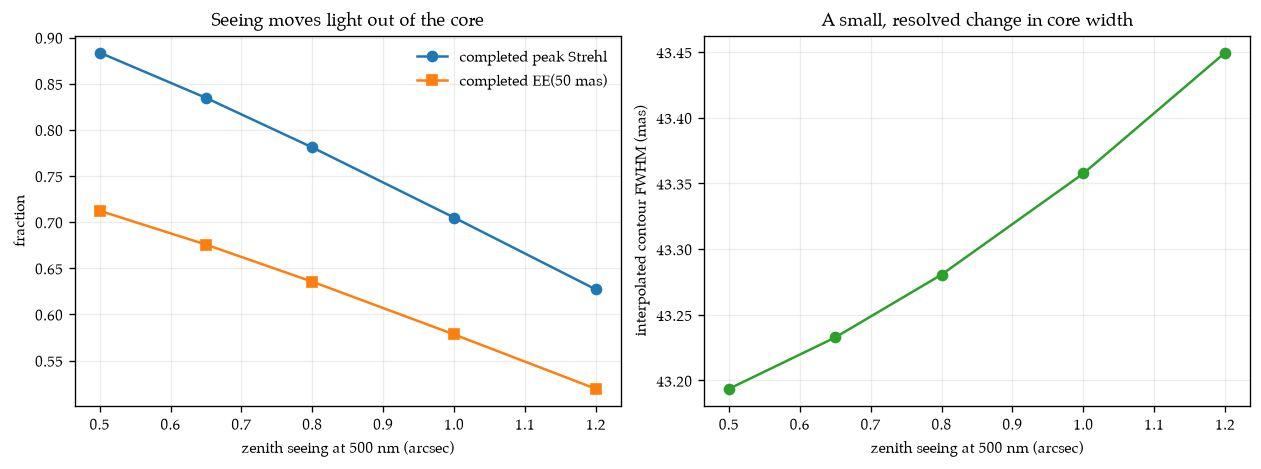

In [7]:
SEEING_VALUES=[0.5,0.65,0.8,1.0,1.2]
seeing_runs={v:baseline if v==0.8 else run_tiptop(override(BASELINE_CONFIG,atmosphere={"Seeing":v}),f"seeing_{v}") for v in SEEING_VALUES}
seeing_table=pd.DataFrame([{"seeing (arcsec)":v,"completed Strehl":r.strehl[0],
    "completed EE(50 mas)":r.ee50mas[0],"completed FWHM (mas)":r.fwhm[0],
    "raw P3 fitting (nm)":r.completed.raw_budget_nm['fitting'][0],
    "completed fitting (nm)":r.completed.completed_budget_nm['fitting'][0],
    "completed total (nm)":r.completed.total_nm[0]} for v,r in seeing_runs.items()]).set_index("seeing (arcsec)")
display(seeing_table.round(5))
fit_ratio=seeing_table['completed fitting (nm)'].iloc[-1]/seeing_table['completed fitting (nm)'].iloc[0]
assert np.isclose(fit_ratio,(1.2/0.5)**(5/6),rtol=1e-10)
print(f"FWHM changes by {np.ptp(seeing_table['completed FWHM (mas)']):.4f} mas; it is weakly sensitive, not invariant.")
fig,axes=plt.subplots(1,2,figsize=(10.4,3.8),layout="constrained")
axes[0].plot(SEEING_VALUES,seeing_table['completed Strehl'],'o-',label="completed peak Strehl")
axes[0].plot(SEEING_VALUES,seeing_table['completed EE(50 mas)'],'s-',label="completed EE(50 mas)")
axes[0].set(xlabel="zenith seeing at 500 nm (arcsec)",ylabel="fraction",title="Seeing moves light out of the core")
axes[0].legend()
axes[1].plot(SEEING_VALUES,seeing_table['completed FWHM (mas)'],'o-',color='C2')
axes[1].set(xlabel="zenith seeing at 500 nm (arcsec)",ylabel="interpolated contour FWHM (mas)",title="A small, resolved change in core width")
fig.savefig(FIG_DIR/"tiptop_seeing_sensitivity.png",bbox_inches="tight")
plt.show()

## 5. Outer scale and vertical profile

A fixed seeing value specifies integrated turbulence strength, not its altitude distribution or outer scale. The outer-scale sweep retains the profile weights; the profile sweep redistributes weight between the ground and free atmosphere while preserving total weight and r0. These changes probe different parts of the PSF and reconstruction.

,completed Strehl,completed EE(50 mas),completed FWHM (mas),open-loop FWHM (mas),completed fitting (nm)
L0 (m),,,,,
10.0,0.79868,0.64447,43.19461,361.86472,71.25211
25.0,0.78092,0.63540,43.28055,485.55379,71.30035
50.0,0.77633,0.63350,43.31506,539.59519,71.30725
100.0,0.77489,0.63298,43.32829,577.34635,71.30897


,r0 at H (m),theta0 at H (arcsec),completed Strehl on axis,completed Strehl at 30 arcsec,completed fitting (nm),tomography on axis (nm)
ground fraction,,,,,,
0.40,0.4836,12.26989,0.73979,0.51326,71.30035,110.45231
0.59,0.4836,16.16104,0.78092,0.58620,71.30035,93.98215
0.75,0.4836,23.46879,0.81745,0.65888,71.30035,77.59857


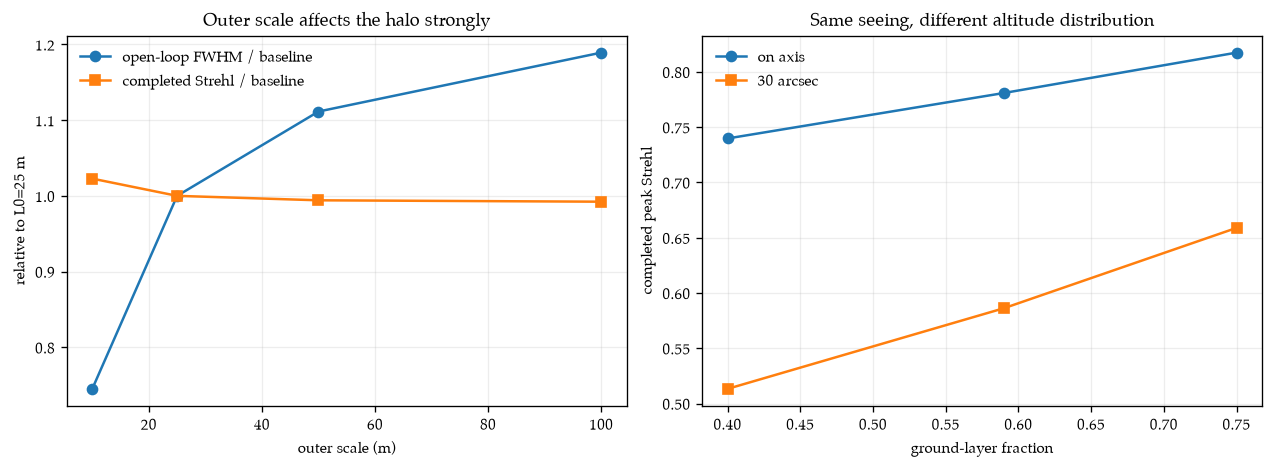

In [8]:
L0_VALUES=[10.0,25.0,50.0,100.0]
l0_runs={v:baseline if v==25 else run_tiptop(override(BASELINE_CONFIG,atmosphere={"L0":v}),f"L0_{v}") for v in L0_VALUES}
l0_table=pd.DataFrame([{"L0 (m)":v,"completed Strehl":r.strehl[0],"completed EE(50 mas)":r.ee50mas[0],
    "completed FWHM (mas)":r.fwhm[0],"open-loop FWHM (mas)":fwhm_contour(r.completed.open_loop,5),
    "completed fitting (nm)":r.completed.completed_budget_nm['fitting'][0]} for v,r in l0_runs.items()]).set_index("L0 (m)")
GROUND_FRACTIONS=[0.4,0.59,0.75]
w0=np.array(BASELINE_CONFIG['atmosphere']['Cn2Weights'])
def redistribute(g):
    w=w0.copy(); w[1:]*=(1-g)/(1-w[0]); w[0]=g
    return w.tolist()
profile_runs={g:baseline if g==0.59 else run_tiptop(override(BASELINE_CONFIG,atmosphere={"Cn2Weights":redistribute(g)}),f"profile_{g}") for g in GROUND_FRACTIONS}
profile_table=pd.DataFrame([{"ground fraction":g,"r0 at H (m)":r.fao.ao.atm.r0,
    "theta0 at H (arcsec)":r.fao.ao.atm.theta0,"completed Strehl on axis":r.strehl[0],
    "completed Strehl at 30 arcsec":r.strehl[-1],"completed fitting (nm)":r.completed.completed_budget_nm['fitting'][0],
    "tomography on axis (nm)":r.completed.completed_budget_nm['tomography'][0]} for g,r in profile_runs.items()]).set_index('ground fraction')
assert np.ptp(profile_table['r0 at H (m)'])<1e-12
assert np.ptp(profile_table['completed fitting (nm)'])<1e-10
display(l0_table.round(5));display(profile_table.round(5))
fig,axes=plt.subplots(1,2,figsize=(10.5,3.8),layout="constrained")
axes[0].plot(L0_VALUES,l0_table['open-loop FWHM (mas)']/l0_table.loc[25,'open-loop FWHM (mas)'],'o-',label='open-loop FWHM / baseline')
axes[0].plot(L0_VALUES,l0_table['completed Strehl']/l0_table.loc[25,'completed Strehl'],'s-',label='completed Strehl / baseline')
axes[0].set(xlabel="outer scale (m)",ylabel="relative to L0=25 m",title="Outer scale affects the halo strongly");axes[0].legend()
axes[1].plot(GROUND_FRACTIONS,profile_table['completed Strehl on axis'],'o-',label='on axis')
axes[1].plot(GROUND_FRACTIONS,profile_table['completed Strehl at 30 arcsec'],'s-',label='30 arcsec')
axes[1].set(xlabel='ground-layer fraction',ylabel='completed peak Strehl',title='Same seeing, different altitude distribution');axes[1].legend()
fig.savefig(FIG_DIR/'tiptop_atmosphere_structure.png',bbox_inches='tight');plt.show()

## 6. Guide-star geometry

The asterism radius changes while detected photons, atmospheric profile, DM hardware, and the reconstruction optimization field are held fixed. The appropriate geometry depends on the specified science field. This is not a universal prescription to maximize or minimize guide-star separation.

,ring 7.5 arcsec,ring 17.5 arcsec,ring 30 arcsec
science field (arcsec),,,
0.0,0.823232,0.780916,0.739765
5.0,0.820999,0.780242,0.739804
10.0,0.803499,0.782388,0.745455
15.0,0.735199,0.787029,0.750815
20.0,0.633677,0.757856,0.737117
25.0,0.527184,0.686886,0.707287
30.0,0.423272,0.586198,0.645576


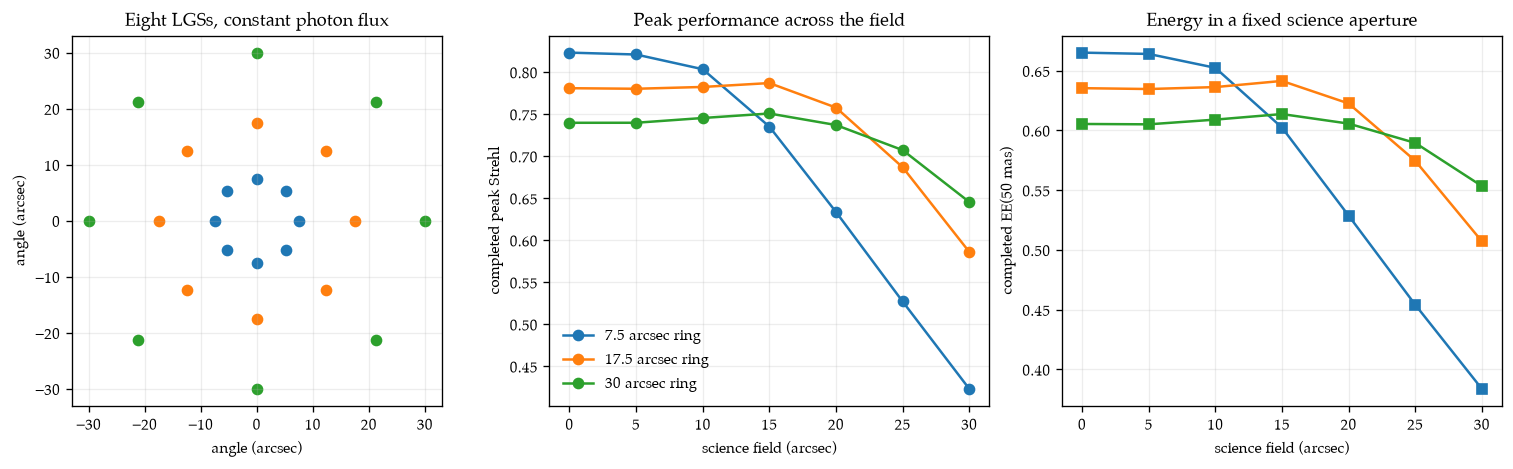

In [9]:
ASTERISM_RADII=[7.5,17.5,30.0]
asterism_runs={v:baseline if v==17.5 else run_tiptop(override(BASELINE_CONFIG,sources_HO={"Zenith":[v]*N_LGS}),f"asterism_{v}") for v in ASTERISM_RADII}
asterism_table=pd.DataFrame({f'ring {v:g} arcsec':r.strehl for v,r in asterism_runs.items()},index=baseline.field)
asterism_table.index.name='science field (arcsec)'
display(asterism_table.round(6))
fig,axes=plt.subplots(1,3,figsize=(12.5,3.8),layout='constrained')
angle=np.deg2rad(np.arange(0,360,45))
for v,r in asterism_runs.items():
    label=f'{v:g} arcsec ring'
    axes[0].scatter(v*np.cos(angle),v*np.sin(angle),label=label)
    axes[1].plot(r.field,r.strehl,'o-',label=label)
    axes[2].plot(r.field,r.ee50mas,'s-',label=label)
axes[0].set(xlabel='angle (arcsec)',ylabel='angle (arcsec)',title='Eight LGSs, constant photon flux');axes[0].set_aspect('equal')
axes[1].set(xlabel='science field (arcsec)',ylabel='completed peak Strehl',title='Peak performance across the field');axes[1].legend()
axes[2].set(xlabel='science field (arcsec)',ylabel='completed EE(50 mas)',title='Energy in a fixed science aperture')
fig.savefig(FIG_DIR/'tiptop_asterism_geometry.png',bbox_inches='tight');plt.show()

## 7. Error budgets: raw P3 and tail-completed model

The tables below retain mutually exclusive terms: servo-lag and tomography replace their combined spatio-temporal term, so there is no double counting. Completed fitting comes from the continuous high-frequency integral; other terms come from P3 with its frequency quadrature expressed consistently. Raw P3 values remain accessible on `run.fao` and in `raw_budget_nm`.

The completed total agrees with the variance used in the OTF for every science direction of every run. This consistency check complements, rather than replaces, the numerical convergence tests.

,fitting,aliasing,servo-lag,tomography,noise,diff. refraction,chromatism,completed total,raw P3 total,raw P3 fitting,OTF closure error
"good seeing, on axis",48.19385,16.75263,20.48873,65.97483,31.65867,12.03740,12.69307,93.18825,86.17328,32.37386,0.0
"median, on axis",71.30035,24.78466,30.31203,93.98215,34.96482,17.80872,18.77875,131.68832,120.76251,47.89548,0.0
"poor seeing, on axis",99.96187,34.74767,42.49695,130.03550,38.83472,24.96752,26.32748,180.94101,165.27169,67.14864,0.0
"median, 30 arcsec",71.30035,24.78466,30.31203,174.53595,45.93052,17.80872,18.77875,199.64729,192.76602,47.89548,0.0
"compact ring, on axis",71.30035,24.78466,30.31203,74.48335,28.50199,17.80872,18.77875,116.81936,104.30258,47.89548,0.0


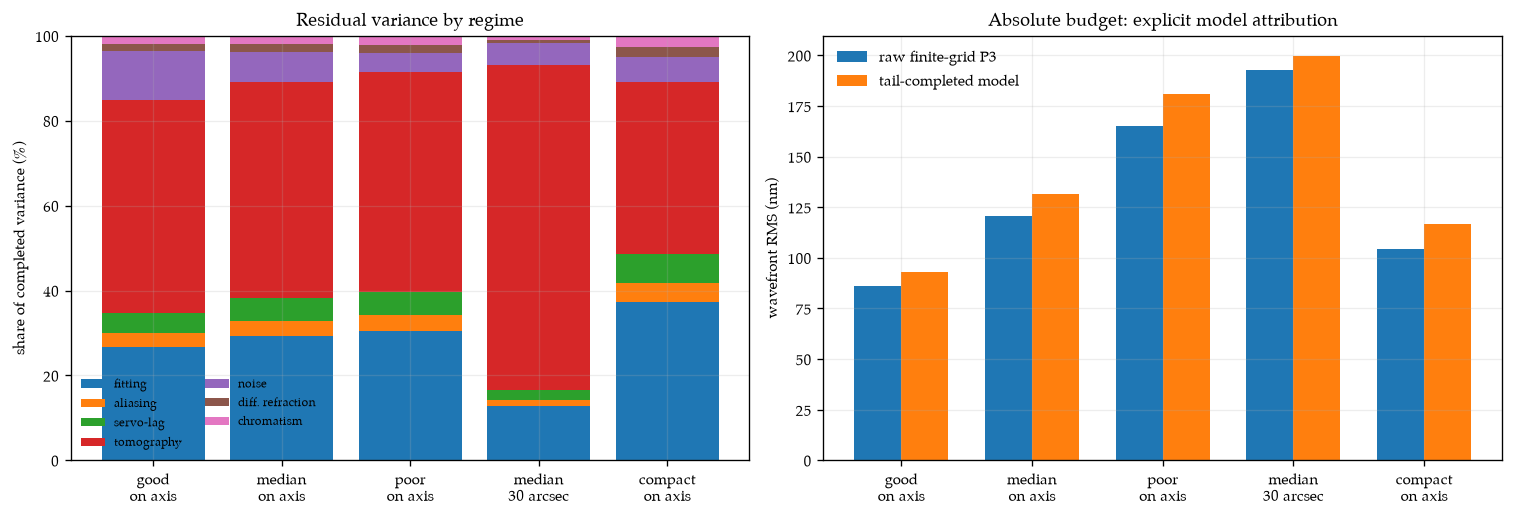

Median on-axis: tomography 93.98 nm (50.9% of variance); fitting 71.30 nm (29.3%).


In [10]:
REGIMES={'good seeing, on axis':(seeing_runs[0.5],0),'median, on axis':(baseline,0),
    'poor seeing, on axis':(seeing_runs[1.2],0),'median, 30 arcsec':(baseline,6),
    'compact ring, on axis':(asterism_runs[7.5],0)}
budget_table=pd.DataFrame({label:{term:values[i] for term,values in r.completed.completed_budget_nm.items()}
                          for label,(r,i) in REGIMES.items()}).T
terms=list(BUDGET_ATTRIBUTES)
budget_table['completed total']=np.sqrt((budget_table[terms]**2).sum(axis=1))
budget_table['raw P3 total']=[r.completed.raw_total_nm[i] for r,i in REGIMES.values()]
budget_table['raw P3 fitting']=[r.completed.raw_budget_nm['fitting'][i] for r,i in REGIMES.values()]
budget_table['OTF closure error']=abs(budget_table['completed total']-np.array([r.completed.total_nm[i] for r,i in REGIMES.values()]))
display(budget_table.round(5))
assert budget_table['OTF closure error'].max()<2e-6
for r in ALL_RUNS:
    assert np.allclose(np.sqrt(sum(v**2 for v in r.completed.completed_budget_nm.values())),r.completed.total_nm,atol=2e-6)
fig,axes=plt.subplots(1,2,figsize=(12.5,4.2),layout='constrained')
x=np.arange(len(REGIMES));bottom=np.zeros(len(x))
shares=budget_table[terms]**2/budget_table['completed total'].to_numpy()[:,None]**2*100
for term in terms:
    axes[0].bar(x,shares[term],bottom=bottom,label=term);bottom+=shares[term]
axes[0].set(ylabel='share of completed variance (%)',ylim=(0,100),title='Residual variance by regime')
axes[0].legend(fontsize=7,ncol=2)
axes[1].bar(x-.18,budget_table['raw P3 total'],width=.36,label='raw finite-grid P3')
axes[1].bar(x+.18,budget_table['completed total'],width=.36,label='tail-completed model')
axes[1].set(ylabel='wavefront RMS (nm)',title='Absolute budget: explicit model attribution');axes[1].legend()
labels=['good\non axis','median\non axis','poor\non axis','median\n30 arcsec','compact\non axis']
for ax in axes:ax.set_xticks(x,labels)
fig.savefig(FIG_DIR/'tiptop_error_budget.png',bbox_inches='tight');plt.show()
median=budget_table.loc['median, on axis']
print(f"Median on-axis: tomography {median['tomography']:.2f} nm "
      f"({100*median['tomography']**2/median['completed total']**2:.1f}% of variance); "
      f"fitting {median['fitting']:.2f} nm ({100*median['fitting']**2/median['completed total']**2:.1f}%).")

## 8. What the study supports

- Increasing seeing moves flux from the core to the halo. The interpolated FWHM changes modestly; EE and Strehl respond more strongly. FWHM is useful for core width and is not a substitute for an energy requirement.
- At fixed integrated seeing, redistributing turbulence changes the tomographic error and field performance. The unchanged completed fitting term is a controlled check that r0 was preserved.
- Asterism geometry trades on-axis performance against field uniformity for this fixed reconstruction field. The tables locate the crossings without claiming a universal optimum.
- Completing the previously truncated fitting tail changes the absolute error budget and lowers the peak. Claims that fitting is negligible must be assessed from the corrected table, not carried over from the original 47.9 nm result.
- Native image-field changes alter both the available high-frequency PSD and the image normalization. They cannot be interpreted solely as crop-energy renormalization.

## 9. Complementarity and limits

TIPTOP/P3 predicts stationary, long-exposure performance under a linear AO model. The explicit time-domain simulator can investigate transients, nonlinear centroiding, saturation, and controller behavior. A gain/delay result from a different small proxy system does not validate the stability of this MCAO configuration.

This study includes no NGS tip/tilt or focus residual, detector nonlinearity, misregistration, static NCPA, sodium-profile variability, or on-sky calibration. Its high-order-only conclusions are conditional on the fixed profile family, photon prescription, and reconstruction field. Omitted low-order errors may also depend on seeing and guide-star availability; their absence is not proof that all swept trends are unaffected.

The adapter completes the high-frequency fitting tail, while retaining P3's sampled correction-band PSD, analytic noise and independence approximations. The convergence study bounds the tested sampling errors; it is not end-to-end validation or a guarantee for other configurations. The finite internal image still folds a small amount of remote halo into its field. Its effect on the quoted core/EE metrics and crop energy is reported in Section 3.

Absolute contour FWHM has a finite focal-pixel sampling bias, separately quantified by the 5→2.5 mas and analytic annular-Airy checks. The small seeing-dependent broadening is resolved with a consistent estimator, but the unchanged-pixel-grid convergence test alone does not establish absolute width accuracy.


## 10. Reproducibility and saved numerical evidence

A fresh repeated baseline checks determinism. The summary below counts actual model evaluations (baseline reuse avoids redundant runs); the high-resolution and quadrature comparisons reuse the same P3 PSD. Machine-readable evidence is written beside the notebook for review together with all five regenerated figures.

In [11]:
repeat=run_tiptop(BASELINE_CONFIG,'baseline_repeat')
repeat_difference=float(np.max(abs(repeat.psfs-baseline.psfs)))
assert repeat_difference<1e-14
summary={
    'versions':check_versions(),
    'model':'P3 correction-band residual plus continuous von Karman fitting tail; MASTSEL PSF propagation',
    'baseline_raw_fitting_nm':float(baseline.completed.raw_budget_nm['fitting'][0]),
    'baseline_wide_raw_fitting_nm':float(wide.completed.raw_budget_nm['fitting'][0]),
    'baseline_completed_fitting_nm':float(baseline.completed.completed_budget_nm['fitting'][0]),
    'baseline_raw_total_nm':baseline.completed.raw_total_nm.tolist(),
    'baseline_completed_total_nm':baseline.completed.total_nm.tolist(),
    'baseline_completed_strehl':baseline.strehl.tolist(),
    'baseline_completed_ee50mas':baseline.ee50mas.tolist(),
    'baseline_crop_energy':baseline.completed.crop_energy.tolist(),
    'max_1024_2048_strehl_change':float(np.max(abs(fine_metrics[0]-base_metrics[0]))),
    'max_1024_2048_ee_change':float(np.max(abs(fine_metrics[1]-base_metrics[1]))),
    'max_1024_2048_fwhm_mas_change':float(np.max(abs(fine_metrics[2]-base_metrics[2]))),
    'max_1024_2048_crop_energy_change':float(np.max(abs(fine.crop_energy-baseline.completed.crop_energy))),
    'max_quadrature_relative_change':float(np.max(abs(quad_metrics-base_metrics)/base_metrics)),
    'max_completed_psf_change_native_fov400_to800':float(np.max(abs(wide.psfs-baseline.psfs))),
    'max_focal_pixel_fwhm_relative_change':float(np.max(abs(focal_metrics[2]/base_metrics[2]-1))),
    'focal_refinement_records':focal_convergence.to_dict(orient='records'),
    'annular_reference_records':annular_rows,
    'max_budget_closure_nm':float(budget_table['OTF closure error'].max()),
    'repeat_max_psf_difference':repeat_difference,
    'n_model_evaluations':len(ALL_RUNS),
    'n_completed_science_psfs':sum(len(r.field) for r in ALL_RUNS),
    'model_plus_completion_runtime_s':sum(r.runtime_s for r in ALL_RUNS),
    'seeing_records':seeing_table.reset_index().to_dict(orient='records'),
    'profile_records':profile_table.reset_index().to_dict(orient='records'),
    'budget_records':budget_table.reset_index().to_dict(orient='records')}
output=ROOT/'notebooks'/'studies'/'tiptop_validation.json'
output.write_text(json.dumps(summary,indent=2)+'\n')
print(json.dumps({k:v for k,v in summary.items() if not isinstance(v,list)},indent=2))
print('Figures:',FIG_DIR)
print('Numerical evidence:',output)

{
  "versions": {
    "astro-tiptop": "1.5.1",
    "astro-p3": "1.6.2",
    "mastsel": "1.5.2"
  },
  "model": "P3 correction-band residual plus continuous von Karman fitting tail; MASTSEL PSF propagation",
  "baseline_raw_fitting_nm": 47.895476098869175,
  "baseline_wide_raw_fitting_nm": 64.92005279342386,
  "baseline_completed_fitting_nm": 71.30034825589287,
  "max_1024_2048_strehl_change": 1.0986763618880957e-06,
  "max_1024_2048_ee_change": 8.875113886364083e-06,
  "max_1024_2048_fwhm_mas_change": 7.324933368835218e-05,
  "max_1024_2048_crop_energy_change": 0.001807113127085036,
  "max_quadrature_relative_change": 9.88343515028969e-13,
  "max_completed_psf_change_native_fov400_to800": 0.0,
  "max_focal_pixel_fwhm_relative_change": 0.003707049688110864,
  "max_budget_closure_nm": 5.968558980384842e-13,
  "repeat_max_psf_difference": 0.0,
  "n_model_evaluations": 15,
  "n_completed_science_psfs": 105,
  "model_plus_completion_runtime_s": 84.03216862492263
}
Figures: /Users/xuhan/Docu